<a href="https://colab.research.google.com/github/sunayan1/professional_photoshoot_generator/blob/main/LoRA_%2B_Stable_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Wed May  6 10:46:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Install Everything needed


In [ ]:
!pip install diffusers transformers accelerate peft torch torchvision datasets Pillow bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.9 MB/s eta 0:00:00


diffusers: Hugging face's library that contains Stable Diffusion and all the image generation tools

transformers: another HF library, handles text understanding

accelerate: makes training faster, handles GPU/CPU automatically

peft: this is the actual LoRA library. PEFT stands for Parameter Efficient Fine Tuning

torch/tochvision: PyTorch, the engine everything runs on

datasets: helps load and manage your training images

Pillow: image processing (opening, resizing photos)

bitsandbytes: lets us use less memory by using smaller number formats



In [ ]:
import torch

print("PyTorch version:",torch.__version__)
print("GPU available:",torch.cuda.is_available())
print("GPU name:",torch.cuda.get_device_name(0)if torch.cuda.is_available() else "No GPU")

PyTorch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


# Module 1: Understanding LoRA
A normal AI model like Stable Diffusion has billions of numbers (called weights) that define how it generates images. Training these model requires and updating each weights takes weeks and costs thousands of dollars.

LoRA: Instead of changing all the weights, it adds tiny side matrices next to the important layers and only train those.

Original Model Weights (frozen, untouched)
        +
LoRA Matrices (small, only these get trained)
        =
Fine-tuned behavior

**Key LoRA settings**:

r(rank): how big the sticky note(defines the learning ability and memory), Higher = more expressive but more memory. start with r=4, r=8

lora_alpha: how loudly the sticky note "speaks" infront of original weight of modules like Stable diffusion.

target_modules: which layers get the sticky notes. For image models: usually attention layers.

# Module 2: Preparing Training images


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google drive mounted!")
print("Drive is now accessible at: /content/drive/MyDrive/")

Mounted at /content/drive
Google drive mounted!
Drive is now accessible at: /content/drive/MyDrive/


drive.mount('/content/drive') connects your Google Drive to the colab session. Entire Drive is accessible like normal folder at /content/drive/MyDrive/


In [ ]:
import os

DRIVE_FOLDER = "/content/drive/MyDrive/LoRA/Dataset"

if os.path.exists(DRIVE_FOLDER):
  all_files=os.listdir(DRIVE_FOLDER)
  print(f"Found {len(all_files)} files in {DRIVE_FOLDER}")
  for f in all_files:
        print(f"  -> {f}")
else:
        print("Folder not found! Check you path again!")

Found 29 files in /content/drive/MyDrive/LoRA/Dataset
  -> frame_0001.png
  -> frame_0002.png
  -> frame_0004.png
  -> frame_0008.png
  -> frame_0005.png
  -> frame_0006.png
  -> frame_0009.png
  -> frame_0011.png
  -> frame_0010.png
  -> frame_0014.png
  -> frame_0015.png
  -> frame_0016.png
  -> frame_0019.png
  -> frame_0024.png
  -> frame_0020.png
  -> frame_0021.png
  -> frame_0022.png
  -> frame_0023.png
  -> Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(3).jpg
  -> Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(4).jpg
  -> Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(5).jpg
  -> Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(6).jpg
  -> Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(7).jpg
  -> Built for the wild. Made to stand out. Introducing HUBA Terra

In [ ]:
import shutil

os.makedirs("training_data/images",exist_ok=True)
os.makedirs("output/lora", exist_ok=True)

valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
copied = 0
skipped = 0

for filename in os.listdir(DRIVE_FOLDER):
  if filename.lower().endswith(valid_extensions):
    src = os.path.join(DRIVE_FOLDER, filename)
    dst = os.path.join("training_data/images",filename)
    shutil.copy2(src,dst)
    print(f"Copied: {filename}")
    copied += 1

  else:
    print(f"skipped (not an image): {filename}")
    skipped += 1
    print(f"\nDone! Copied: {copied}, skipped: {skipped}")

Copied: frame_0001.png
Copied: frame_0002.png
Copied: frame_0004.png
Copied: frame_0008.png
Copied: frame_0005.png
Copied: frame_0006.png
Copied: frame_0009.png
Copied: frame_0011.png
Copied: frame_0010.png
Copied: frame_0014.png
Copied: frame_0015.png
Copied: frame_0016.png
Copied: frame_0019.png
Copied: frame_0024.png
Copied: frame_0020.png
Copied: frame_0021.png
Copied: frame_0022.png
Copied: frame_0023.png
Copied: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(3).jpg
Copied: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(4).jpg
Copied: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(5).jpg
Copied: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(6).jpg
Copied: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(7).jpg
Copied: Built for the wild. Made to stand out. Intr

so basically, whats happening is src give the path of the dataset stored in the google drive and dst is the destination i.e. in the RAM for faster accessing of dataset for training.  

shutil.copy2 copies the metadata of data from src to dst.

In [ ]:
from PIL import Image

target_size = 512

image_folder = "training_data/images"
processed = 0
skipped = 0

for filename in os.listdir(image_folder):
  if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
    print(f"Skipping non-image file: {filename}")
    skipped += 1
    continue

  image_path = os.path.join(image_folder, filename)

  img = Image.open(image_path)

  img = img.resize((target_size, target_size), Image.LANCZOS)

  img.save(image_path)

  processed += 1
  print(f"Processed: {filename}")

print(f"\n Done! Processed: {processed}, Skipped : {skipped}")

Processed: frame_0001.png
Processed: frame_0008.png
Processed: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(8).jpg
Processed: frame_0010.png
Processed: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(12).jpg
Processed: frame_0004.png
Processed: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(7).jpg
Processed: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(10).jpg
Processed: frame_0009.png
Processed: frame_0016.png
Processed: frame_0019.png
Processed: frame_0023.png
Processed: frame_0011.png
Processed: frame_0006.png
Processed: frame_0024.png
Processed: frame_0002.png
Processed: frame_0020.png
Processed: Built for the wild. Made to stand out. Introducing HUBA Terrain T-shirt. #HUBA #MadeInNepal(4).jpg
Processed: frame_0021.png
Processed: frame_0015.png
Processed: frame_0014.png
Processed: Built for the wild. M

.resize((w,h), Image.LANCZOS) resized the image. LANCZOS is a high quality resizing method.

# Previewing Images

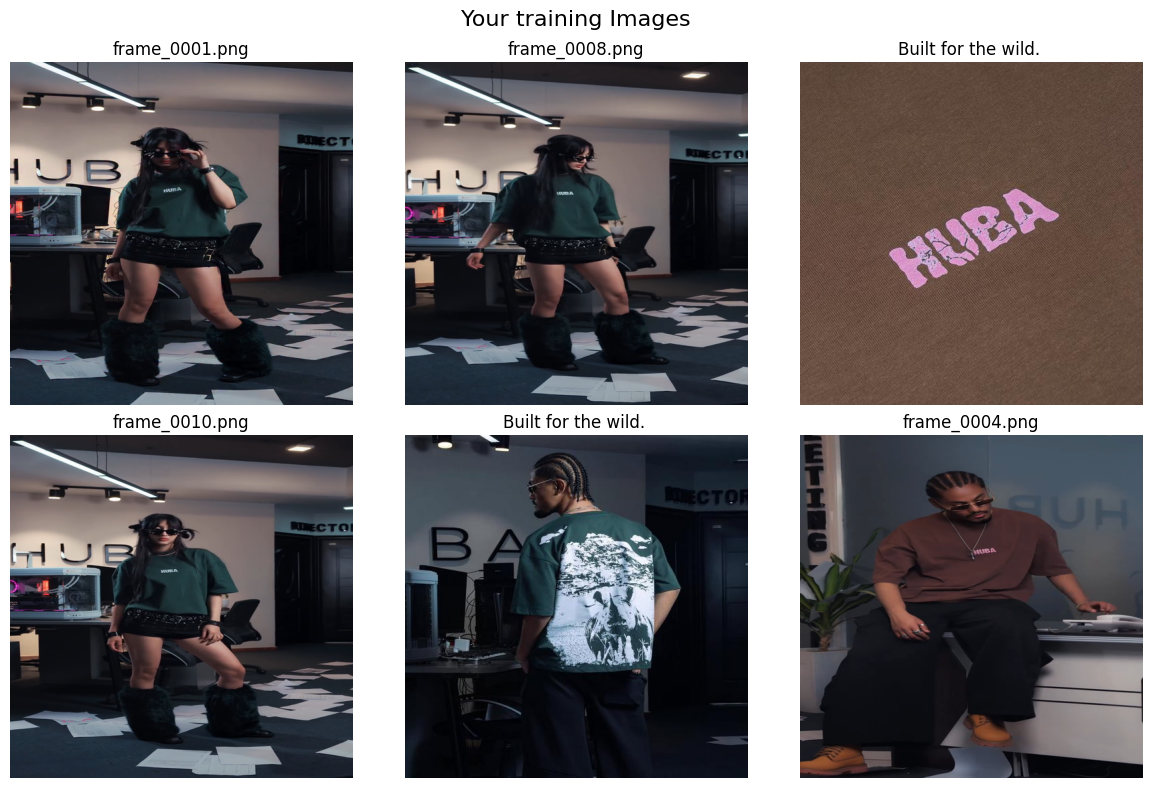

In [ ]:
import matplotlib.pyplot as plt

image_files = os.listdir("training_data/images")
image_files = [f for f in image_files if f.endswith(('.jpg', '.jpeg', '.png'))]

num_to_show = min(6, len(image_files))
fig, axes = plt.subplots(2,3, figsize=(12,8))
axes = axes.flatten()

for i in range(num_to_show):
  img = Image.open(f"training_data/images/{image_files[i]}")
  axes[i].imshow(img)
  axes[i].set_title(image_files[i][:20])
  axes[i].axis('off')

for i in range(num_to_show, len(axes)):
  axes[i].axis('off')

plt.suptitle("Your training Images", fontsize=16)
plt.tight_layout()
plt.show()

**matplotlib.pyplot** is a Python's main plotting library.

**plt.subplots**(2,3, figsize(12,8)) creates a figure and grid of subplots. 2,3 denotes 2 rows and 3 columns. figsize gives the width and height.

**axes.flatten()** converts the 2x3 matrix of axes into a 1D list for easy indexing. such that: axes[0], axes[1],etc

**axes[i].imshow(img)** displays the image inside subplot number i.

**plt.tight_layout()** automatically adjusts spacing between subplots.

# Module 3: Loading the Base Model

In [ ]:
#Defining Configuration set
MODEL_NAME = "runwayml/stable-diffusion-v1-5"
TRIGGER_WORD = "ohwx"
PRODUCT_TYPE = "clothe"
NUM_EPOCHS = 100
BATCH_SIZE = 1
LEARNING_RATE = 1e-4
LORA_RANK = 8

In [ ]:
from diffusers import StableDiffusionPipeline, DDPMScheduler
import torch

print("Loading base model...(may take 3-5minutes)")
print("It's downloading ~4gb - wait for it!\n")

pipe= StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,  #use 16-bit numbers to save memory
    safety_checker=None,
)

print("Pipeline loaded!")
print("Components inside the pipeline:")
print("  - pipe.unet         → the main image generation network")
print("  - pipe.text_encoder → converts your prompt to numbers")
print("  - pipe.vae          → compresses/decompresses images")
print("  - pipe.tokenizer    → splits your text into tokens")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading base model...(may take 3-5minutes)
It's downloading ~4gb - wait for it!



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Pipeline loaded!
Components inside the pipeline:
  - pipe.unet         → the main image generation network
  - pipe.text_encoder → converts your prompt to numbers
  - pipe.vae          → compresses/decompresses images
  - pipe.tokenizer    → splits your text into tokens


**from diffusers import StableDiffusionPipeline, DDPMScheduler**: imports two classes from the diffusers library.

**StableDiffusionPipeline**: a complete ready-to-run Stable Diffusion model(text encoder, UNet, VAE, tokenizer, etc)

**DDPMScheduler**: controls the diffusion noise scheduling process (how noise is added/removed during generation)

**pipe = StableDiffusionPipeline.from_pretrained()**: starts loading a pretrained Stable Diffusion model. pipe becomes the entire model pipeline.

**torch_dtype** loads the model in 16-bit floating point precision. It uses half the GPU memory and runs much faster.

**safety_checker=None**: disbales the built-in NSFW content filter.

In [ ]:
#we only need the unet for LoRA training

unet = pipe.unet
#move UNet to GPU
unet = unet.to("cuda")

#Check its size
total_params = sum(p.numel() for p in unet.parameters())
print(f"UNet total parameters: {total_params:,}")
print(f"That's {total_params / 1e6:.1f} million parameters")
print(f"\nLoRA will only train a tiny fraction of these!")

UNet total parameters: 859,520,964
That's 859.5 million parameters

LoRA will only train a tiny fraction of these!


**pipe.unet**: accesses the UNet component from your loaded pipeline.

**.to("cuda"): moves the model from CPU RAM to GPU VRAM(video memory).

**sum(p.numel() for p in unet.parameters()): counts every single trainiable numbers in the UNet.

**numel()** = "number of elements"

**:,**: inside the f-string format, adds comma separators to big numbers (like 86,000,000 instead of 86000000)

**/ 1e6**: divides by 1 million to get a readable number

# Modules 4: Applying LoRA to the Model

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha= LORA_RANK,
    target_modules=[
        "to_q",       #query projection in attention layers
        "to_k",       #key projection in attention layers
        "to_v",       #value projection in attentino layers
        "to_out.)",   #output projection in attention layers
    ],
    lora_dropout=0.1, #Randomly diable 10% of Lora during trainig
    bias="none",
)


print("LoRA config created!")
print(f"  Rank (r): {lora_config.r}")
print(f"  Target modules: {lora_config.target_modules}")
print(f"  Dropout: {lora_config.lora_dropout}")

LoRA config created!
  Rank (r): 8
  Target modules: {'to_v', 'to_out.)', 'to_q', 'to_k'}
  Dropout: 0.1


In [ ]:
!pip install -U torchao>=0.16.0
!pip install -U peft

In [ ]:
#applying LoRA to the UNet
unet_with_lora = get_peft_model(unet,lora_config)

unet_with_lora.print_trainable_parameters()

trainable params: 1,195,008 || all params: 860,715,972 || trainable%: 0.1388


**get_peft_model(unet, lora_config)**: this takes your UNet and your config, and wraps the target layers with LoRA matrices. The original weights are frozen. Only the new LoRA matrices are trainable.

**.print_trainable_parameters()**: shows you exactly how many parameters LoRA addes vs total.

# Module 5: The Training Loop

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class ProductDataset(Dataset):
  """Custom datasets that loads your product images"""

  def __init__(self, image_folder, trigger_word, product_type):
    self.image_folder = image_folder
    self.trigger_word = trigger_word
    self.product_type = product_type

    self.image_paths = [
        os.path.join(image_folder,f)
        for f in os.listdir(image_folder)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    #define image transformation
    self.transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])

    print(f"Dataset ready! Found {len(self.image_paths)} images")

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self,index):
    img = Image.open(self.image_paths[index]).convert("RGB")
    img_tensor = self.transform(img)

    caption = f"a photo of {self.trigger_word} {self.product_type}, product photogrphy, studio lighting, professional"

    return {
        "pixel_values": img_tensor,
        "caption": caption
    }


**class ProductDataset(dataset)**: defines a class. Dataset in parentheses means it inherits from PyTorch's Dataset class, it has to follow certain rules (__len__, __getitem__)

**transforms.Compose([...])**: chains multiple image transformations together in order.

**transforms.ToTensor()**: converts PIL image to a PyTorch tensor.

**transforms.Nomalize([0.5], [0.5])**: shifts pixel values from [0,1] to [-1,1]. SD was trained expecting this range.

In [ ]:
#Create the dataset

dataset = ProductDataset(
    image_folder="training_data/images",
    trigger_word=TRIGGER_WORD,
    product_type=PRODUCT_TYPE
)

dataloader = DataLoader(
    dataset,
    batch_size= BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print(f"\nDataloder ready!")
print(f" Total images: {len(dataset)}")
print(f" Batch Size: {BATCH_SIZE}")
print(f" Steps per epoch: {len(dataloader)}")

sample_batch = next(iter(dataloader))
print(f"\nSample batch:")
print(f"  Image tensor shape: {sample_batch['pixel_values'].shape}")
print(f"  Caption: {sample_batch['caption'][0]}")

Dataset ready! Found 28 images

Dataloder ready!
 Total images: 28
 Batch Size: 1
 Steps per epoch: 28

Sample batch:
  Image tensor shape: torch.Size([1, 3, 512, 512])
  Caption: a photo of ohwx clothe, product photogrphy, studio lighting, professional


In [ ]:
from torch.optim import AdamW
from transformers import CLIPTokenizer, CLIPTextModel

tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder.to("cuda")
vae = pipe.vae.to("cuda")  #compresses/decompresses images

optimizer = AdamW(
    unet_with_lora.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01
)

print("Optimizer ready!")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Optimizing {sum(p.numel() for p in unet_with_lora.parameters() if p.requires_grad)} parameters")

Optimizer ready!
Learning rate: 0.0001
Optimizing 1195008 parameters


**pipe.tokenizer**: the tokenizer converts the prompt into a list of numbers the model understands.

**pipe.text_encoder**: a CLIP model that converts those numbers into rich vector embeddings.

**pipe.vae**: Variational Autoencoder.Compresses 512x512 images down to small 64x64 "latent" representations for efficiency.

**AdamW(unet_with_lora.parameters(), lr=...)**: AdamW is an optimizer that implements "adaptive learning rates with weight decay".

In [ ]:
from diffusers import DDPMScheduler
import torch.nn.functional as F

noise_scheduler = DDPMScheduler.from_pretrained(MODEL_NAME, subfolder="scheduler")

unet_with_lora.train()

print("Starting training!")
print("="*50)

for epoch in range(NUM_EPOCHS):
  total_loss = 0

  for step, batch in enumerate(dataloader):
    #encode images to latent space
    images = batch["pixel_values"].to("cuda", dtype=torch.float16)
    with torch.no_grad():
      latents = vae.encode(images).latent_dist.sample()
      latents = latents * vae.config.scaling_factor

    #add random noise to latents
    noise = torch.randn_like(latents)
    timesteps = torch.randint(0, 1000, (BATCH_SIZE,), device="cuda").long()
    noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

    #encode the caption
    captions = batch["caption"]
    tokens = tokenizer(captions, padding="max_length", max_length=77, truncation=True, return_tensors="pt")
    with torch.no_grad(): #again we dont train text encoder
      text_embeddings = text_encoder(tokens.input_ids.to("cuda"))[0]

    #predict the noise
    noise_pred = unet_with_lora(
        noisy_latents,
        timesteps,
        encoder_hidden_states=text_embeddings
    ).sample

    #calculate how wrong the prediction was
    loss = F.mse_loss(noise_pred.float(), noise.float())

    #backpropagate and update weights
    optimizer.zero_grad() #clears old gradient
    loss.backward()       # calculate each weight using back propagation
    optimizer.step()      # actually updates model weight

    total_loss += loss.item()

  if(epoch+1) % 10 == 0:
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Avg Loss: {avg_loss:.4f}")

print("\n Training Completed!")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Starting training!
Epoch 10/100 | Avg Loss: 0.1045
Epoch 20/100 | Avg Loss: 0.1118
Epoch 30/100 | Avg Loss: 0.0758
Epoch 40/100 | Avg Loss: 0.0685
Epoch 50/100 | Avg Loss: 0.1302
Epoch 60/100 | Avg Loss: 0.1362
Epoch 70/100 | Avg Loss: 0.1355
Epoch 80/100 | Avg Loss: 0.1044
Epoch 90/100 | Avg Loss: 0.1130
Epoch 100/100 | Avg Loss: 0.0898

 Training Completed!


**noise_scheduler** = DDPMScheduler.from_pre_trained() loads the same noise schedule that the model was originally trained on. Esures LoRA training is compatible with the model's diffusion process.

**unet_with_lora.train()**: tell pytorch enable training behavior.

**for step, batch in enumerate(dataloader):**: for each batch in the dataset, set = the batch number we are on. batch = images/captions for that batch.

**with torch.no_grad():**: says dont calculate gradients here. because we are not training vae, only UNet.  

**vae.encode(images).latent_dist.sample()**: vae compresses image, instead of working with full image pixels, we work in compressed form.

**latents * vae.config.scaling_factor**: scales latent values properly, keeps training stable.

**torch.randn_like(latents)**: creates random noise (same shape as latents)

**timesteps**: picks random noise level for each image.

**noisy_latents**= adds the noise to each latent

**tokens**: turns the caption of each images into the number that machine understands



In [ ]:
import os
DRIVE_SAVE_PATH = "/content/drive/MyDrive/LoRA/my_lora_output"

os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
unet_with_lora.save_pretrained(DRIVE_SAVE_PATH)

print(f"✅ LoRA saved to Google Drive at: {DRIVE_SAVE_PATH}")

✅ LoRA saved to Google Drive at: /content/drive/MyDrive/LoRA/my_lora_output


**save_pretrained**: saves only the LoRA adapter weights, not the full SD model.

Loading pipeline for inference...


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

pipeline + lora loaded!

Generating with prompt:
'a professional model wearing ohwx clothe, fashion photography, studio lighting, white background, 8K, high quality'



  0%|          | 0/30 [00:00<?, ?it/s]

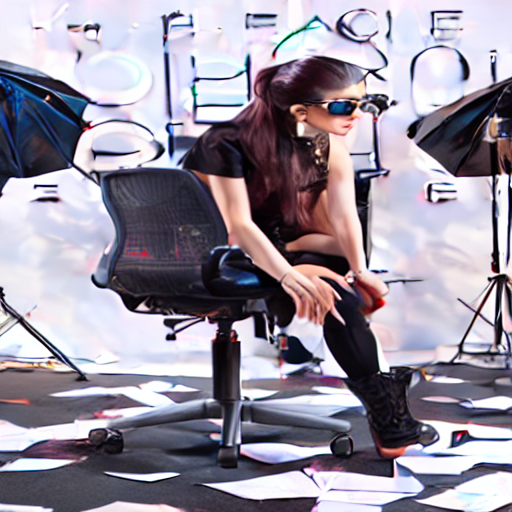

In [ ]:
from peft import PeftModel

print("Loading pipeline for inference...")
inference_pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    safety_checker=None
).to("cuda")

inference_pipe.unet = PeftModel.from_pretrained(inference_pipe.unet, DRIVE_SAVE_PATH)
print("pipeline + lora loaded!")

prompt = f"a professional model wearing {TRIGGER_WORD} {PRODUCT_TYPE}, fashion photography, studio lighting, white background, 8K, high quality"
negative_prompt = "blurry, low quality, distorted, ugly, amateur, bad lighting"

print(f"\nGenerating with prompt:\n'{prompt}'\n")

image = inference_pipe(
    prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,    # More steps = higher quality but slower
    guidance_scale=7.5,        # How strictly to follow the prompt (7-9 is standard)
    height=512,
    width=512,
).images[0]

image.save("output/test_generation.png")
image  # Display in Colab